### Import libraries

In [2]:
%matplotlib inline
import os
import sys
import csv
import torch
import pathlib
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sb

### Import Autoencoder class

In [4]:
folder_path = str(pathlib.Path().resolve().parents[1])
print("Folder path =", folder_path)
sys.path.append(folder_path + '/Notebooks/AE_class/')
from Conv_AE_weebots_downsampled import *

Folder path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder


### Check libraries versions

In [6]:
print(f"torch version: {torch.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sb.__version__}")

torch version: 2.2.1+cu121
numpy version: 1.26.4
matplotlib version: 3.8.0
seaborn version: 0.12.2


### Check GPU

In [8]:
print("CUDA is available =", torch.cuda.is_available())
print("CUDA device count =", torch.cuda.device_count())
if torch.cuda.device_count() > 1:
    os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
#print(torch.cuda.current_device())
#print(torch.cuda.device(0))
print("CUDA device name =", torch.cuda.get_device_name(0))

CUDA is available = True
CUDA device count = 2
CUDA device name = NVIDIA RTX A5000


### Hyperparameters

In [10]:
save_plots = False
normalize_ratemaps = True

In [11]:
#Model
n_hidden = 200
batch_size = 256
num_epochs = 100
learning_rate = 1e-4
C_factor = 1e3
alpha = 1e5

#Others
experiment_n = 1
trial_t = 0

envs = ['Tmaze_old1', 'Tmaze_old2', 'Tmaze_old3']

### Import ratemaps

In [13]:
CACHE_DIR = folder_path + "/Models/Control-Exp" + str(experiment_n) + "_cache_ratemaps"
cache_path = os.path.join(CACHE_DIR, f"ratemaps.npy")

arr = np.load(cache_path, mmap_mode="r")  # no full load into RAM
print('arr shape =', arr.shape)

arr shape = (301, 200, 50, 50)


In [14]:
#Normalize ratemaps
if normalize_ratemaps == True:
    normal_arr = []
    
    for mt in range(len(arr)):
        mt_arr = []
        for unit in range(n_hidden):
            ratemap = arr[mt][unit]
            if np.max(ratemap) != 0.0:
                mt_arr.append(ratemap / np.max(ratemap))
            else:
                mt_arr.append(ratemap)
    
        normal_arr.append(mt_arr)
    
    arr = np.array(normal_arr)

In [15]:
loss_csv_filename = CACHE_DIR + '/loss_history.csv'

history_loss = []
with open(loss_csv_filename, mode='r', newline='') as file:
    reader = csv.DictReader(file)
    for row in reader:
        value = row.get('Image_loss')
        history_loss.append(float(value))

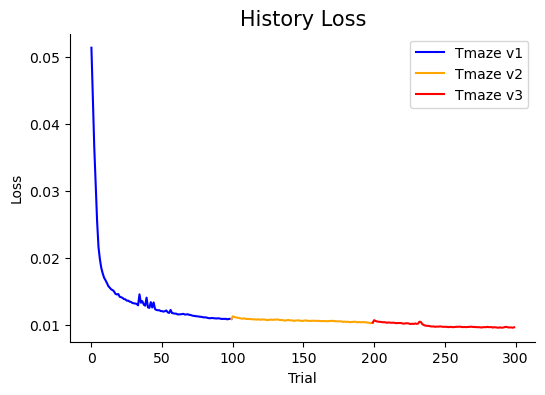

In [16]:
fig = plt.figure(figsize=(6,4))
plt.plot(range(0, 100), history_loss[:100], color='blue', label='Tmaze v1')
plt.plot(range(99, 200), history_loss[99:200], color='orange', label='Tmaze v2')
plt.plot(range(199, 300), history_loss[199:], color='red', label='Tmaze v3')

plt.xlabel('Trial')
plt.ylabel('Loss')
sb.despine()
plt.legend()
plt.title('History Loss', fontsize=15)
plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/History_loss.png', format='png')

### Explore ratemaps at environment m and trial t

In [18]:
trial_idx = 99
trial_ratemaps = arr[trial_idx]
trial_ratemaps.shape

(200, 50, 50)

In [19]:
plot_ratemaps(trial_ratemaps[:100], 'plot_folder_path', save=False)

In [20]:
peak_activity = []
for i in range(n_hidden):
    peak_activity.append(np.max(arr[trial_idx][i]))

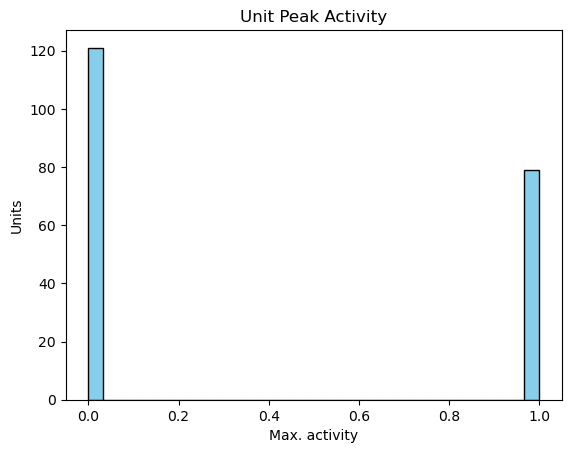

Silent units = 121.0


In [21]:
hist = plt.hist(peak_activity, bins=30, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Max. activity')
plt.ylabel('Units')
plt.title('Unit Peak Activity')

# Display the plot
plt.show()

print('Silent units =', hist[0][0])

In [22]:
def get_num_active_units(ratemaps, actv_threshold):
    active_units = 0
    for i in range(len(ratemaps)):
        peak = np.max(ratemaps[i])
        if peak > actv_threshold:
            active_units += 1
    return active_units
#####################################################################    

def get_max_coverage(ratemaps, actv_threshold):
    #TDefine maximal firing coverage once, at the first trial of the first environment
    max_size = 0
    
    for i in range(len(ratemaps)):
        size = np.sum(ratemaps[i] > actv_threshold)
        if size > max_size:
            max_size = size

    print("Max. coverage =", max_size)
    return max_size
#####################################################################

def get_mean_unit_coverage_at_t(ratemaps, max_coverage, actv_threshold):
    #Normalize the activation coverage of each unit.
    unit_coverage = []
    
    for i in range(len(ratemaps)):
        unit_coverage.append(np.sum(ratemaps[i] > actv_threshold) / max_coverage)

    # Define mean unit coverage of (only) active units
    mean_unit_coverage = np.mean([x for x in unit_coverage if x != 0.0])
    
    return mean_unit_coverage
#####################################################################

def representative_unit_sums(ratemaps):
    #Take 4 reference points for measuring summed activity at representative locations
    top_left_unit_sum = np.sum(ratemaps[:, 40, 10])
    top_center_unit_sum = np.sum(ratemaps[:, 40, 25])
    top_right_unit_sum = np.sum(ratemaps[:, 40, 40])
    bottom_center_unit_sum = np.sum(ratemaps[:, 10, 25])
    return top_left_unit_sum, top_center_unit_sum, top_right_unit_sum, bottom_center_unit_sum
#####################################################################

def representative_unit_count(ratemaps, actv_threshold):
    #Take 4 reference points for measuring the number of active units at representative locations
    top_left_unit_count = np.sum(ratemaps[:, 40, 10] > actv_threshold)
    top_center_unit_count = np.sum(ratemaps[:, 40, 25] > actv_threshold)
    top_right_unit_count = np.sum(ratemaps[:, 40, 40] > actv_threshold)
    bottom_center_unit_count = np.sum(ratemaps[:, 10, 25] > actv_threshold)
    return top_left_unit_count, top_center_unit_count, top_right_unit_count, bottom_center_unit_count
#####################################################################

In [23]:
actv_threshold = 0.01
num_active_units = []
mean_unit_coverage_history = []

TL_rep_unit_sum_history = []
TC_rep_unit_sum_history = []
TR_rep_unit_sum_history = []
BC_rep_unit_sum_history = []

TL_rep_unit_count_history = []
TC_rep_unit_count_history = []
TR_rep_unit_count_history = []
BC_rep_unit_count_history = []

correlation_history = []

for t in range(arr.shape[0]):
    if t == 0:
        max_coverage = get_max_coverage(arr[t], actv_threshold)
    
    num_active_units.append(get_num_active_units(arr[t], actv_threshold))
    mean_unit_coverage_history.append(get_mean_unit_coverage_at_t(arr[t], max_coverage, actv_threshold))

    # Unit activity at representative locations
    TL_sum, TC_sum, TR_sum, BC_sum = representative_unit_sums(arr[t])
    TL_rep_unit_sum_history.append(TL_sum)
    TC_rep_unit_sum_history.append(TC_sum)
    TR_rep_unit_sum_history.append(TR_sum)
    BC_rep_unit_sum_history.append(BC_sum)
    
    TL_count, TC_count, TR_count, BC_count = representative_unit_count(arr[t], actv_threshold)
    TL_rep_unit_count_history.append(TL_count)
    TC_rep_unit_count_history.append(TC_count)
    TR_rep_unit_count_history.append(TR_count)
    BC_rep_unit_count_history.append(BC_count)

    # Measure map correlation
    if t != 0:
        flat_t0 = prev_ratemaps.flatten()
        flat_t1 = arr[t].flatten()
        corr = np.corrcoef(flat_t0, flat_t1)[0, 1]
        correlation_history.append(corr)

    prev_ratemaps = arr[t]
    

Max. coverage = 1832


## Plotting functions

In [25]:
def hide_ticks(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

#####################################################################################################

def add_colorbar(ax, im):
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction & pad for size and spacing
    cbar.ax.tick_params(labelsize=8)  # Adjust tick label size

#####################################################################################################

def plot_active_units_count(num_active_units, figsize=(6,4), save=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)
    plt.plot(range(1, num_epochs+1), num_active_units[1:num_epochs+1], color='blue', label='Tmaze v1')
    plt.plot(range(num_epochs, (num_epochs*2)+1), num_active_units[num_epochs:(num_epochs*2)+1], color='orange', label='Tmaze v2')
    plt.plot(range((num_epochs*2), (num_epochs*3)+1), num_active_units[(num_epochs*2):], color='red', label='Tmaze v3')
    plt.scatter(range(0, 1), num_active_units[:1], color='black', label='Pre', s=25)
    
    
    plt.xlabel('Epoch')
    plt.ylabel('Units (out of 200)')
    sb.despine()
    plt.legend()
    plt.title('Active units count', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Active_units.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Active_units.png', format='png')

#####################################################################################################

def plot_unit_coverage(mean_unit_coverage, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    plt.plot(range(1, num_epochs+1), mean_unit_coverage[1:num_epochs+1], color='blue', label='Tmaze v1')
    plt.plot(range(num_epochs, (num_epochs*2)+1), mean_unit_coverage[num_epochs:(num_epochs*2)+1], color='orange', label='Tmaze v2')
    plt.plot(range((num_epochs*2), (num_epochs*3)+1), mean_unit_coverage[(num_epochs*2):], color='red', label='Tmaze v3')
    plt.scatter(range(0, 1), mean_unit_coverage[:1], color='black', label='Pre', s=25)
    
    plt.xlabel('Trial')
    plt.ylabel('Coverage (%)')
    sb.despine()
    plt.legend()
    plt.title('Mean Unit Coverage', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Unit_coverage.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Unit_coverage.png', format='png')

#####################################################################################################

def plot_activity_rep_loc(BC_rep_unit_sum_history, TL_rep_unit_sum_history, TC_rep_unit_sum_history, TR_rep_unit_sum_history, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    plt.plot(BC_rep_unit_sum_history[1:], label='Bottom-Center', color='#1f77b4')
    plt.plot(TL_rep_unit_sum_history[1:], label='Top-Left', color='#ff7f0e')
    plt.plot(TC_rep_unit_sum_history[1:], label='Top-Center', color='#2ca02c')
    plt.plot(TR_rep_unit_sum_history[1:], label='Top-Right', color='#d62728')
    plt.scatter(range(0, 1), BC_rep_unit_sum_history[:1], color='#1f77b4', s=15)
    plt.scatter(range(0, 1), TL_rep_unit_sum_history[:1], color='#ff7f0e', s=15)
    plt.scatter(range(0, 1), TC_rep_unit_sum_history[:1], color='#2ca02c', s=15)
    plt.scatter(range(0, 1), TR_rep_unit_sum_history[:1], color='#d62728', s=15)
    
    
    plt.xlabel('Trial')
    plt.ylabel('Sum activity')
    sb.despine()
    plt.title('Sum actv. at representative locations', fontsize=15)
    plt.legend()
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Rep_locations.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Rep_locations.png', format='png')
        
#####################################################################################################

def plot_units_rep_loc(BC_rep_unit_count_history, TL_rep_unit_count_history, TC_rep_unit_count_history, TR_rep_unit_count_history, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    plt.plot(BC_rep_unit_count_history[1:], label='Bottom-Center', color='#1f77b4')
    plt.plot(TL_rep_unit_count_history[1:], label='Top-Left', color='#ff7f0e')
    plt.plot(TC_rep_unit_count_history[1:], label='Top-Center', color='#2ca02c')
    plt.plot(TR_rep_unit_count_history[1:], label='Top-Right', color='#d62728')
    plt.scatter(range(0, 1), BC_rep_unit_count_history[:1], color='#1f77b4', s=15)
    plt.scatter(range(0, 1), TL_rep_unit_count_history[:1], color='#ff7f0e', s=15)
    plt.scatter(range(0, 1), TC_rep_unit_count_history[:1], color='#2ca02c', s=15)
    plt.scatter(range(0, 1), TR_rep_unit_count_history[:1], color='#d62728', s=15)
    
    
    plt.xlabel('Trial')
    plt.ylabel('Freq.')
    sb.despine()
    plt.title('Active units at representative locations', fontsize=15)
    plt.legend()
    plt.show()
        
#####################################################################################################

def plot_cogmap_correlation(correlation_history, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    plt.plot(range(1, num_epochs), correlation_history[1:num_epochs], color='blue', label='Tmaze v1')
    plt.plot(range(num_epochs-1, (num_epochs*2)), correlation_history[num_epochs-1:(num_epochs*2)], color='orange', label='Tmaze v2')
    plt.plot(range((num_epochs*2)-1, (num_epochs*3)), correlation_history[(num_epochs*2)-1:], color='red', label='Tmaze v3')
    plt.scatter(range(0, 1), correlation_history[:1], color='black', label='Pre', s=25)
    
    plt.xlabel('Trial')
    plt.ylabel('Pearson Correlation')
    sb.despine()
    plt.legend(loc=4)
    plt.title('Cog. Maps similarity (t vs. t–1)', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Map_similarity.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Map_similarity.png', format='png')

#####################################################################################################

def plot_img_reconstruction(input_img, mt0, mt50, mt100, figsize=(14,3), m0_bool=False, save_plots=False, plot_folder_path=''):

    fig = plt.figure(figsize=figsize)
    plt.subplot(141)
    plt.imshow(input_img)
    plt.suptitle('Image reconstruction', fontsize=15)
    plt.title('Input', fontsize=10)
    plt.ylabel('Tmaze v3')
    
    plt.subplot(142)
    plt.imshow(predict(input_img, mt0))
    if m0_bool == True:
        plt.title('Trial 0', fontsize=10)
    else:
        plt.title('Trial 1', fontsize=10)

    plt.subplot(143)
    plt.imshow(predict(input_img, mt50))
    plt.title('Trial 50', fontsize=10)

    plt.subplot(144)
    plt.imshow(predict(input_img, mt100))
    plt.title('Trial 100', fontsize=10)

    plt.show()
    
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Tmaze3_img_recon.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Tmaze3_img_recon.png', format='png')

#####################################################################################################

def plot_example_ratemaps_progress(example_units, example_ratemaps, figsize=(15, 8), save_plots=False, plot_folder_path=''):
    
    fig, axes = plt.subplots(5, 9, figsize=figsize)
    colors = ['blue'] * 3 + ['orange'] * 3 + ['red'] * 3
    ts = ['0', '10', '100', '1', '10', '100', '1', '10', '100']

    for i, ax in enumerate(axes.flatten()):
        # Determine the column index (0–8)
        col = i % 9
        color = colors[col]
    
        # Draw dashed T-maze using the color for this column
        ax.axhline(y=35, xmin=0, xmax=0.3, color=color, linestyle='--', linewidth=2)
        ax.axhline(y=35, xmin=0.7, xmax=1, color=color, linestyle='--', linewidth=2)
        ax.axhline(y=49, xmin=0, xmax=1, color=color, linestyle='--', linewidth=2)
        ax.axhline(y=0, xmin=0.3, xmax=0.7, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=35, ymin=0, ymax=0.7, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=15, ymin=0, ymax=0.7, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=0, ymin=0.7, ymax=1, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=49, ymin=0.7, ymax=1, color=color, linestyle='--', linewidth=2)
    
    for mt in range(len(example_ratemaps)):
        for unit in range(len(example_ratemaps[mt])):
            im = axes[unit, mt].imshow(example_ratemaps[mt][unit], cmap='hot', origin='lower')
            hide_ticks(axes[unit, mt])
            if mt == 0: axes[unit, mt].set_ylabel("Unit " + str(example_units[unit]), fontsize=15, labelpad=10)
            if unit == 0: axes[unit, mt].set_title('T' + ts[mt], fontsize=15)

    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/example_units.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/example_units.png', format='png')

## Model update functions

In [27]:
def format_dataset(env):
    data_path = folder_path + '/Datasets/' + env
    csv_filename = data_path + "/data.csv"

    img_filename_list = os.listdir(data_path)
    num_images = len(img_filename_list) -1 

    return data_path, csv_filename, num_images

#####################################################################

def Load_env_dataset(env_idx):
    # Load dataset every T-maze version
    env = envs[env_idx] #Choose environment index
    data_path, csv_filename, num_images = format_dataset(env)

    print("Dataset Path =", data_path)
    print("Num. Images in Dataset =", num_images)
    
    dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)

    return dataset, csv_filename
    
#####################################################################

def update_model_trial(experiment_n, env_idx, trial):
    # Update model name for trial t
    env = envs[env_idx]
    trial_t = trial
    model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
    foldername = 'Control-Exp' + str(experiment_n) + '-NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)

    model_folder_path = folder_path + '/Models/' + foldername
    model_path = model_folder_path + '/' + model_filename
    #print('Model loaded =', model_filename)

    model = Conv_AE(n_hidden=n_hidden)
    model.load_state_dict(torch.load(model_path))

    return model

## Serial results

In [29]:
mean_unit_coverage = [x * 100 for x in mean_unit_coverage_history] #Compute percentages

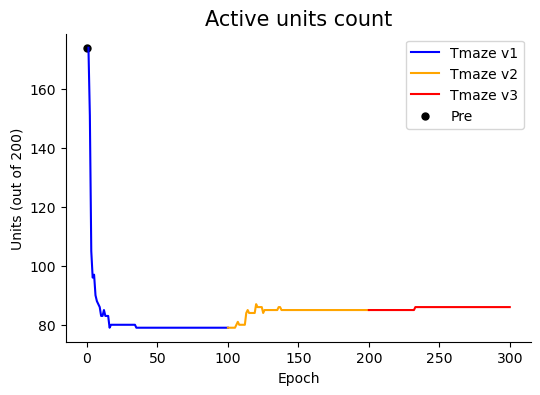

In [30]:
plot_active_units_count(num_active_units, figsize=(6,4))

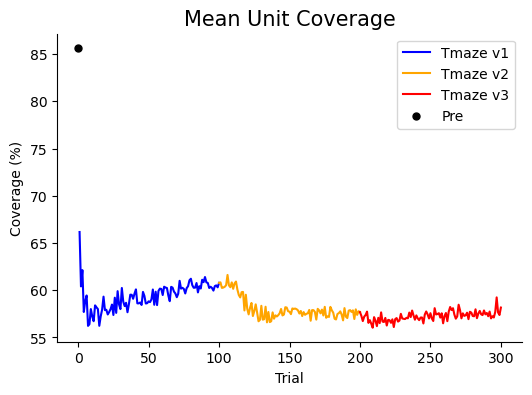

In [31]:
plot_unit_coverage(mean_unit_coverage, figsize=(6,4))

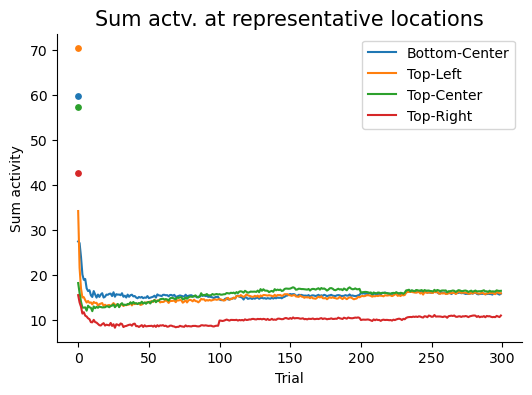

In [32]:
plot_activity_rep_loc(BC_rep_unit_sum_history, TL_rep_unit_sum_history, TC_rep_unit_sum_history, TR_rep_unit_sum_history, figsize=(6,4))

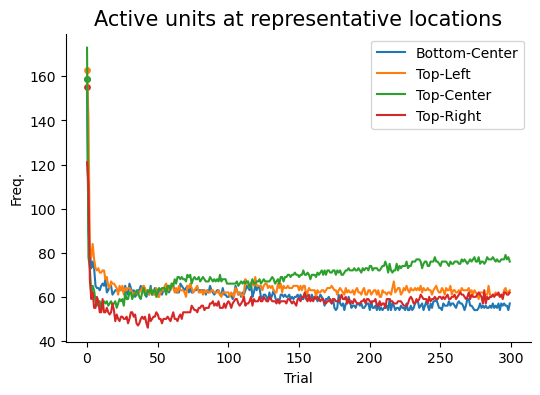

In [33]:
plot_units_rep_loc(BC_rep_unit_count_history, TL_rep_unit_count_history, TC_rep_unit_count_history, TR_rep_unit_count_history, figsize=(6,4))

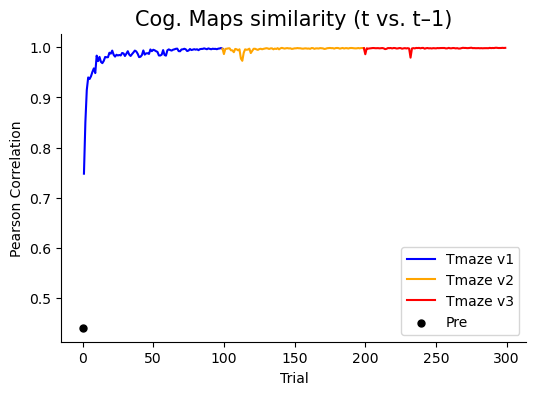

In [34]:
plot_cogmap_correlation(correlation_history, figsize=(6,4))

Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_old1
Num. Images in Dataset = 39998


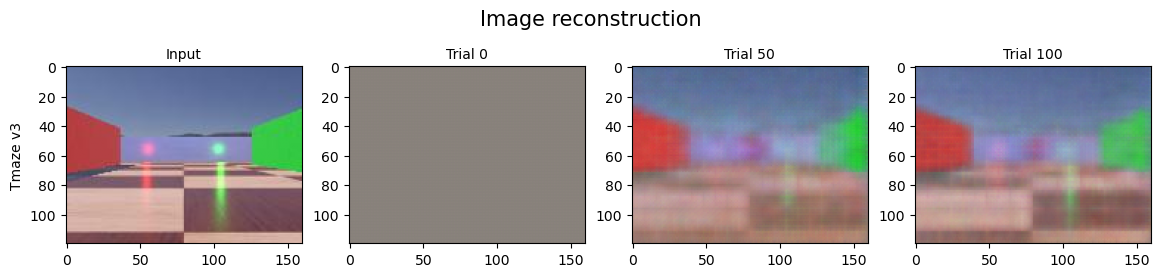

In [35]:
img_idx = 0

m = 0
m0t0 = update_model_trial(experiment_n, env_idx=m, trial=0)
m0t50 = update_model_trial(experiment_n, env_idx=m, trial=50)
m0t100 = update_model_trial(experiment_n, env_idx=m, trial=100)

dataset, _ = Load_env_dataset(m)
m0_input = dataset[img_idx]

plot_img_reconstruction(m0_input, m0t0, m0t50, m0t100, m0_bool=True)

Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_old2
Num. Images in Dataset = 39998


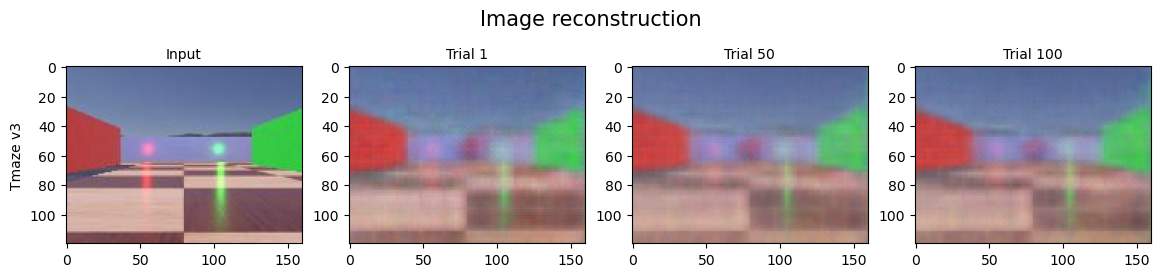

In [36]:
m = 1
m1t0 = update_model_trial(experiment_n, env_idx=m, trial=1)
m1t50 = update_model_trial(experiment_n, env_idx=m, trial=50)
m1t100 = update_model_trial(experiment_n, env_idx=m, trial=100)

dataset, _ = Load_env_dataset(m)
m1_input = dataset[img_idx]

plot_img_reconstruction(m1_input, m1t0, m1t50, m1t100)

Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_old3
Num. Images in Dataset = 39998


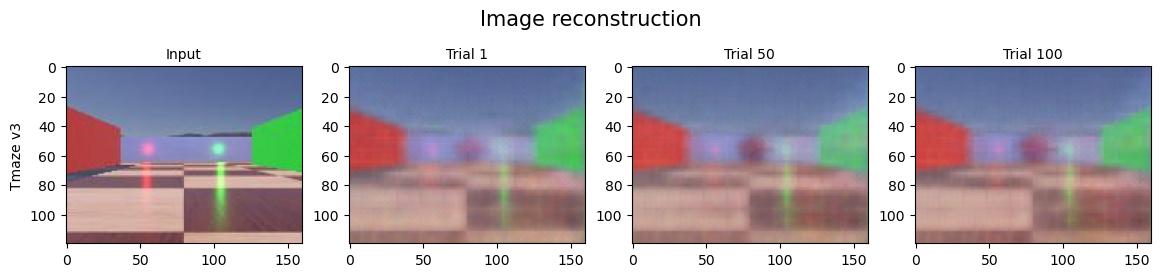

In [37]:
m = 2
m2t0 = update_model_trial(experiment_n, env_idx=m, trial=1)
m2t50 = update_model_trial(experiment_n, env_idx=m, trial=50)
m2t100 = update_model_trial(experiment_n, env_idx=m, trial=100)

dataset, _ = Load_env_dataset(m)
m2_input = dataset[img_idx]

plot_img_reconstruction(m2_input, m2t0, m2t50, m2t100)

In [38]:
unit_1 = 0
unit_2 = 50
unit_3 = 100
unit_4 = 150
unit_5 = 199

In [39]:
m0t0_ratemap1 = arr[0][unit_1]
m0t0_ratemap2 = arr[0][unit_2]
m0t0_ratemap3 = arr[0][unit_3]
m0t0_ratemap4 = arr[0][unit_4]
m0t0_ratemap5 = arr[0][unit_5]

m0t10_ratemap1 = arr[10][unit_1]
m0t10_ratemap2 = arr[10][unit_2]
m0t10_ratemap3 = arr[10][unit_3]
m0t10_ratemap4 = arr[10][unit_4]
m0t10_ratemap5 = arr[10][unit_5]

m0t100_ratemap1 = arr[100][unit_1]
m0t100_ratemap2 = arr[100][unit_2]
m0t100_ratemap3 = arr[100][unit_3]
m0t100_ratemap4 = arr[100][unit_4]
m0t100_ratemap5 = arr[100][unit_5]
####################################

m1t1_ratemap1 = arr[101][unit_1]
m1t1_ratemap2 = arr[101][unit_2]
m1t1_ratemap3 = arr[101][unit_3]
m1t1_ratemap4 = arr[101][unit_4]
m1t1_ratemap5 = arr[101][unit_5]

m1t10_ratemap1 = arr[110][unit_1]
m1t10_ratemap2 = arr[110][unit_2]
m1t10_ratemap3 = arr[110][unit_3]
m1t10_ratemap4 = arr[110][unit_4]
m1t10_ratemap5 = arr[110][unit_5]

m1t100_ratemap1 = arr[200][unit_1]
m1t100_ratemap2 = arr[200][unit_2]
m1t100_ratemap3 = arr[200][unit_3]
m1t100_ratemap4 = arr[200][unit_4]
m1t100_ratemap5 = arr[200][unit_5]
####################################

m2t1_ratemap1 = arr[201][unit_1]
m2t1_ratemap2 = arr[201][unit_2]
m2t1_ratemap3 = arr[201][unit_3]
m2t1_ratemap4 = arr[201][unit_4]
m2t1_ratemap5 = arr[201][unit_5]

m2t10_ratemap1 = arr[210][unit_1]
m2t10_ratemap2 = arr[210][unit_2]
m2t10_ratemap3 = arr[210][unit_3]
m2t10_ratemap4 = arr[210][unit_4]
m2t10_ratemap5 = arr[210][unit_5]

m2t100_ratemap1 = arr[300][unit_1]
m2t100_ratemap2 = arr[300][unit_2]
m2t100_ratemap3 = arr[300][unit_3]
m2t100_ratemap4 = arr[300][unit_4]
m2t100_ratemap5 = arr[300][unit_5]

example_units = [unit_1, unit_2, unit_3, unit_4, unit_5]

example_ratemaps = [[m0t0_ratemap1, m0t0_ratemap2, m0t0_ratemap3, m0t0_ratemap4, m0t0_ratemap5],
                    [m0t10_ratemap1, m0t10_ratemap2, m0t10_ratemap3,m0t10_ratemap4, m0t10_ratemap5],
                    [m0t100_ratemap1, m0t100_ratemap2, m0t100_ratemap3, m0t100_ratemap4, m0t100_ratemap5],
                    [m1t1_ratemap1, m1t1_ratemap2, m1t1_ratemap3, m1t1_ratemap4, m1t1_ratemap5],
                    [m1t10_ratemap1, m1t10_ratemap2, m1t10_ratemap3, m1t10_ratemap4, m1t10_ratemap5],
                    [m1t100_ratemap1, m1t100_ratemap2, m1t100_ratemap3, m1t100_ratemap4, m1t100_ratemap5],
                    [m2t1_ratemap1, m2t1_ratemap2, m2t1_ratemap3, m2t1_ratemap4, m2t1_ratemap5], 
                    [m2t10_ratemap1, m2t10_ratemap2, m2t10_ratemap3, m2t10_ratemap4, m2t10_ratemap5],
                    [m2t100_ratemap1, m2t100_ratemap2, m2t100_ratemap3, m2t100_ratemap4, m2t100_ratemap5]]

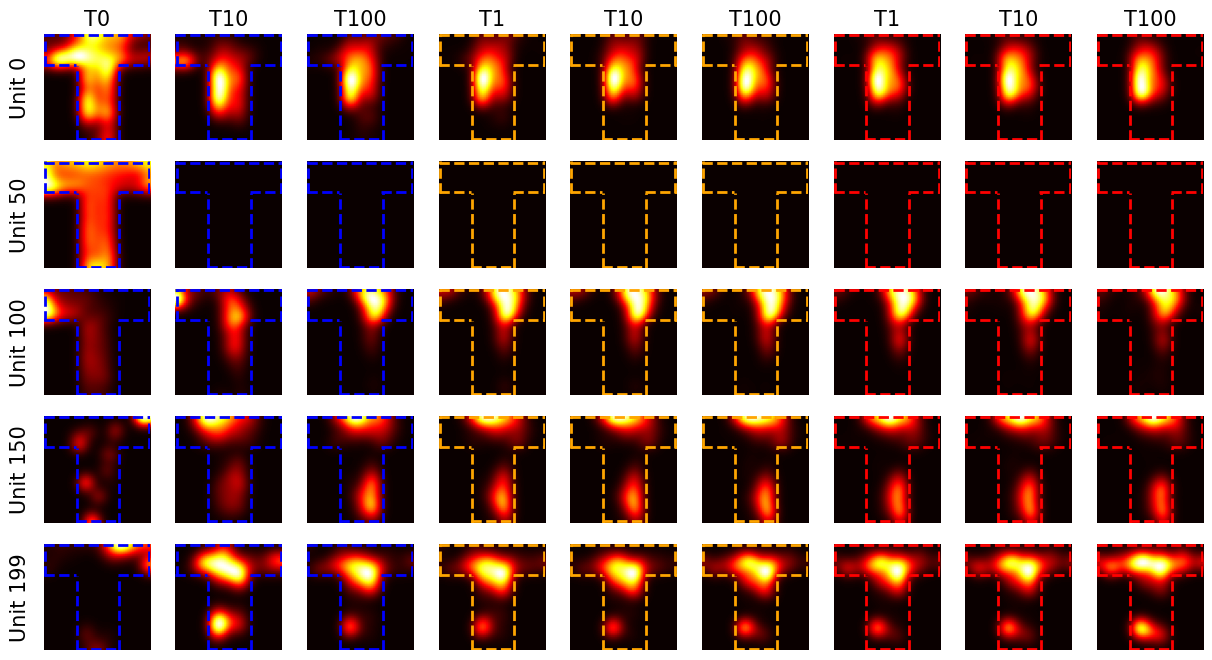

In [40]:
plot_example_ratemaps_progress(example_units, example_ratemaps)